In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def create_dataset_2(xy_min,xy_max,nb_samples,radius=5):
  """
  """
  samples= np.random.uniform(low=xy_min, high=xy_max, size=(nb_samples,2))
  sample_norm=np.linalg.norm(samples,axis=1)
  classes=(sample_norm>=radius+np.random.uniform(low=-2, high=2, size=(nb_samples))).astype(float)
  df = pd.DataFrame({'x1': samples[:,0],'x2': samples[:,1],'class':classes})
  color_map={1:'r',0:'b'}
  df['color']=df['class'].apply(lambda x:color_map[x])
  return df

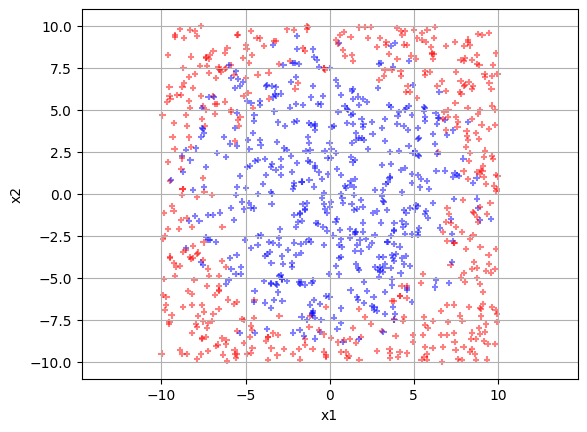

In [3]:
train_df=create_dataset_2(xy_min=[-10,-10],xy_max=[10,10],nb_samples=1000,radius=8)
ax = train_df.plot.scatter(x='x1',y='x2',c='color',marker='+',alpha=.5)
ax.grid('on')
ax.axis('equal')
plt.savefig('logistic_regression_nonlinear_dataset.png',bbox_inches='tight')
plt.show()

In [4]:
train_samples = train_df[['x1','x2']].values.astype(np.float32)
train_targets = train_df[['class']].values.astype(np.float32)

In [5]:
import tensorflow as tf

def create_logistic_regression_model(input_dim):
   '''
   Create a logistic regression model
   Inputs:
   input_dim: input dimention
   Outputs:
   model: logistic regression model
   '''
   inputs = tf.keras.Input(shape=(input_dim,))
   outputs = tf.keras.layers.Dense(units=1,activation='sigmoid',name='prediction_layer')(inputs)
   model = tf.keras.Model(inputs,outputs,name='logistic_regression')
   return model

In [ ]:
def line_points(a, b, c):
    """Plots the line ax + by + c = 0.

    Args:
        a: Coefficient of x.
        b: Coefficient of y.
        c: Constant term.
    """
    if b == 0:  # Handle the case where the line is vertical
        if a == 0:
            raise ValueError("Invalid equation: a and b cannot both be zero.")
        y = np.array([v for v in range(-5,6)])
        x = (-c / a)*np.ones((y.shape[0]))
    else:
        x = np.array([-5, 5]) # Example range: x from -5 to 5
        y = (-a * x - c) / b
    return x, y

In [6]:
input_dim = train_samples.shape[1]
model=create_logistic_regression_model(input_dim=input_dim)

learning_rate = 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate)
model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])

nb_epochs = 200
history = model.fit(train_samples,train_targets,batch_size=256,epochs=nb_epochs)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4856 - loss: 3.1483 
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4958 - loss: 3.0467
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5016 - loss: 3.0364
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4976 - loss: 3.0464
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4884 - loss: 2.9885
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4990 - loss: 2.9861
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4755 - loss: 3.0946
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5068 - loss: 2.9242
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4898 - loss: 2.9234
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4920 - loss: 3.0451
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4854 - loss: 2.9733
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4933 - lo

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


/tmp/ipython-input-1784166391.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


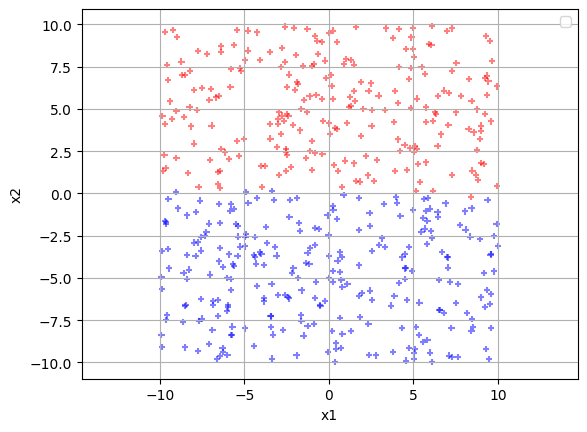

In [7]:
test_df=create_dataset_2(xy_min=[-10,-10],xy_max=[10,10],nb_samples=500,radius=7)
test_samples=test_df[['x1','x2']].astype(np.float32)
test_targets=np.array(test_df[['class']].astype(np.float32))
predictions=model.predict(test_samples)

predicted_classes=[int(pred[0]>0.5) for pred in predictions]
color_map={1:'r',0:'b'}
prediction_color=[color_map[c] for c in predicted_classes]

ax = test_df.plot.scatter(x='x1',y='x2',c=prediction_color,marker='+',alpha=.5)
ax.grid('on')
ax.axis('equal')
ax.legend()
plt.savefig('logistic_regression_nonlinear_dataset_linear_classification.png',bbox_inches='tight')
plt.show()

In [8]:
for k1 in ['x1','x2']:
  for k2 in ['x1','x2']:
    train_df[f'{k1}*{k2}']=train_df[k1]*train_df[k2]

train_df.head()

,x1,x2,class,color,x1*x1,x1*x2,x2*x1,x2*x2
0,-1.097180,5.730585,0.0,b,1.203804,-6.287484,-6.287484,32.839602
1,-1.922205,9.378223,0.0,b,3.694871,-18.026864,-18.026864,87.951062
2,-3.087715,-5.866838,0.0,b,9.533985,18.115124,18.115124,34.419784
3,8.410489,-8.634478,1.0,r,70.736326,-72.620184,-72.620184,74.554212
4,-3.470672,0.113307,0.0,b,12.045562,-0.393251,-0.393251,0.012838


In [14]:
train_samples=train_df[['x1','x2','x1*x1','x1*x2','x2*x1','x2*x2']].values.astype(np.float32)
train_targets=train_df[['class']].values.astype(np.float32)
input_dim=train_samples.shape[1]

input_dim = train_samples.shape[1]
model=create_logistic_regression_model(input_dim=input_dim)

learning_rate = 0.01
optimizer = tf.keras.optimizers.Adam(learning_rate)
model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])

nb_epochs = 200
history = model.fit(train_samples,train_targets,batch_size=256,epochs=nb_epochs)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5486 - loss: 2.9641 
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5431 - loss: 2.4807
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5537 - loss: 2.0642
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5397 - loss: 1.8675
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5402 - loss: 1.5564
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6104 - loss: 1.2413
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6148 - loss: 1.1264
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5950 - loss: 1.0935
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5897 - loss: 1.0443
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6423 - loss: 0.9688
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6353 - loss: 0.8447
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5999 - l

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


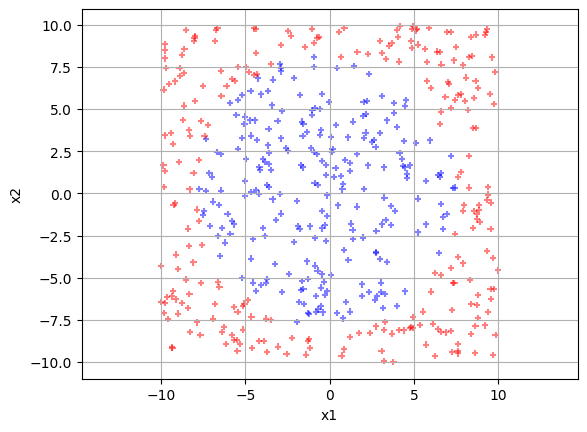

In [15]:
test_df=create_dataset_2(xy_min=[-10,-10],xy_max=[10,10],nb_samples=500,radius=7)
for k1 in ['x1','x2']:
  for k2 in ['x1','x2']:
    test_df[f'{k1}*{k2}']=test_df[k1]*test_df[k2]

test_samples=test_df[['x1','x2','x1*x1','x1*x2','x2*x1','x2*x2']].astype(np.float32)
test_targets=np.array(test_df[['class']].astype(np.float32))
predictions=model.predict(test_samples)

predicted_classes=[int(pred[0]>0.5) for pred in predictions]
color_map={1:'r',0:'b'}
prediction_color=[color_map[c] for c in predicted_classes]

ax = test_df.plot.scatter(x='x1',y='x2',marker='+',c=prediction_color,alpha=.5)
ax.grid('on')
ax.axis('equal')
plt.savefig('logistic_regression_nonlinear_dataset_nonlinear_classification.png',bbox_inches='tight')
plt.show()